# DSCI 552 — Homework 2

**Name:** Yuanda SHI  
**USC ID:** 6635-4638-05

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import display

sns.set_theme(style="whitegrid")

ALPHA = 0.05
RANDOM_STATE = 42

## 1. Combined Cycle Power Plant Data Set

### 1(a) Load Sheet 1

Load the Combined Cycle Power Plant dataset from the
first sheet of Folds5x2_pp.xlsx.

In [3]:
DATA_PATH = Path("data/CCPP/Folds5x2_pp.xlsx")

assert DATA_PATH.is_file(), (
    f"Missing dataset: {DATA_PATH.resolve()}"
)

with pd.ExcelFile(DATA_PATH) as workbook:
    print("Available sheets:", workbook.sheet_names)
    df = pd.read_excel(workbook, sheet_name=0)

df = df.rename(columns={
    "AT": "T",
    "PE": "EP"
})

features = ["T", "AP", "RH", "V"]
required_columns = features + ["EP"]

assert set(required_columns).issubset(df.columns)

df = df[required_columns].copy()

display(df.head())
print("Data shape:", df.shape)

Available sheets: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4', 'Sheet5']


,T,AP,RH,V,EP
0,14.96,1024.07,73.17,41.76,463.26
1,25.18,1020.04,59.08,62.96,444.37
2,5.11,1012.16,92.14,39.40,488.56
3,20.86,1010.24,76.64,57.32,446.48
4,10.82,1009.23,96.62,37.50,473.90


Data shape: (9568, 5)


### 1(b)i

Report the number of rows and columns, and describe
what each row and column represents.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

display(df.dtypes.to_frame("dtype"))

Rows: 9568
Columns: 5
Column names: ['T', 'AP', 'RH', 'V', 'EP']

Missing values:
T     0
AP    0
RH    0
V     0
EP    0
dtype: int64


,dtype
T,float64
AP,float64
RH,float64
V,float64
EP,float64


### 1(b)ii

Create pairwise scatterplots of every predictor
and the response variable. Describe the findings.

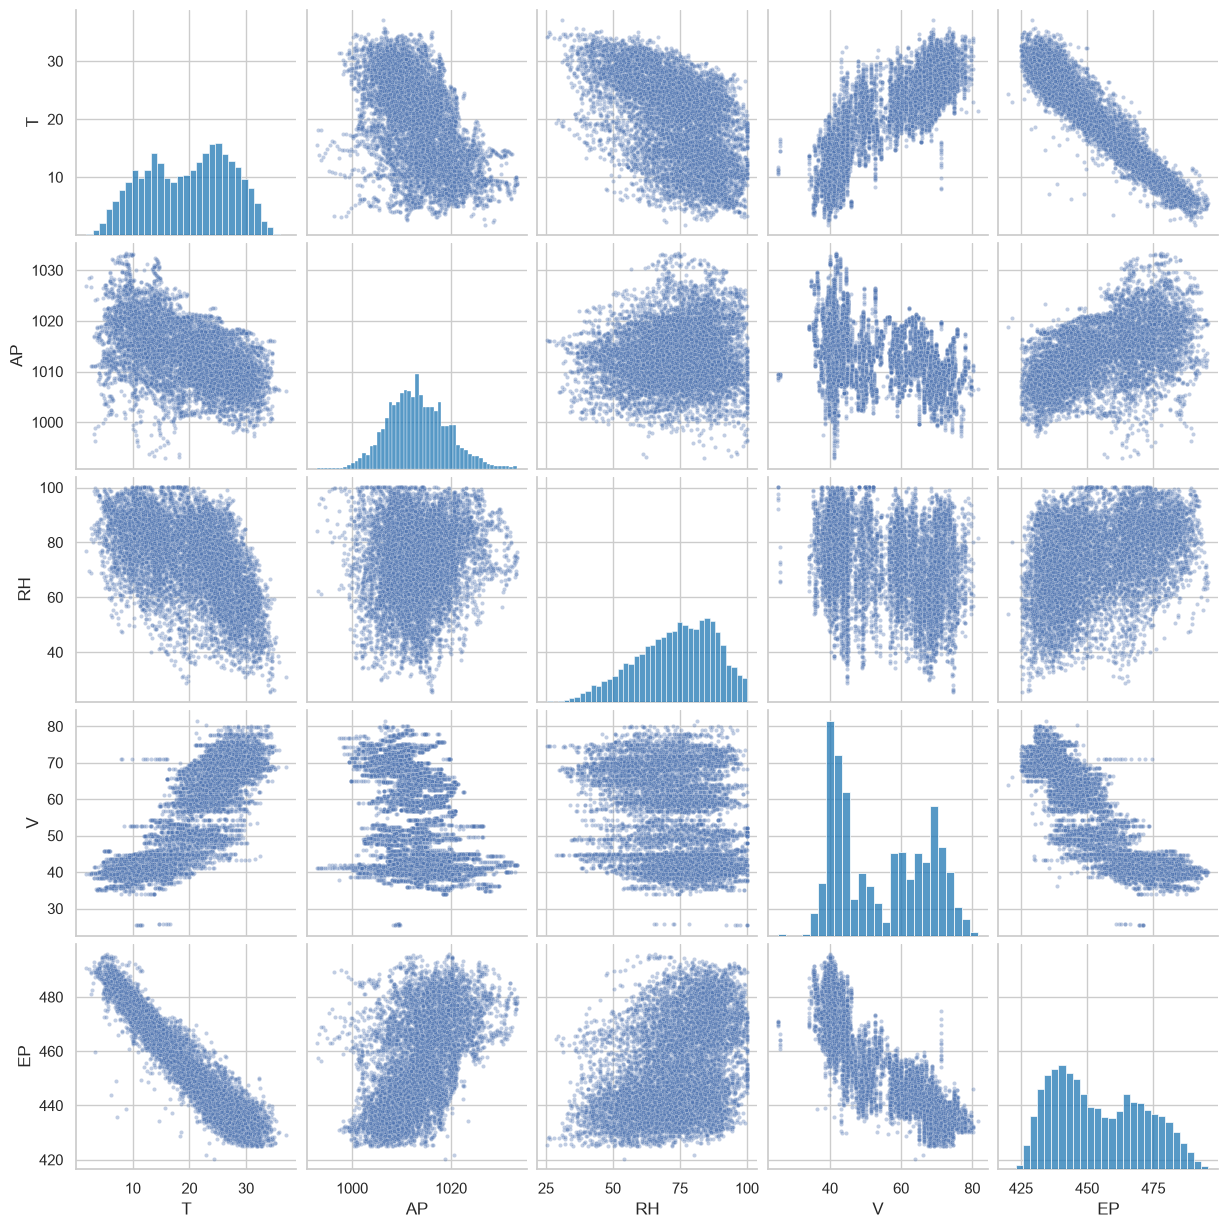

In [5]:
sns.pairplot(
    df[required_columns],
    plot_kws={"s": 9, "alpha": 0.35},
    diag_kind="hist",
    diag_kws={"color": "tab:blue"}
)

plt.show()

**Observations:**
The pairwise scatterplots reveal the following relationships:

1. **Temperature (T) vs. Energy Output (EP):** There is a strong negative relationship. As temperature increases, energy output tends to decrease. The relationship appears approximately linear, although some variation and potential outliers are present.

2. **Ambient Pressure (AP) vs. EP:** There is a weak to moderate positive relationship between ambient pressure and energy output. The observations are widely scattered, suggesting that ambient pressure alone may have limited predictive power.

3. **Relative Humidity (RH) vs. EP:** The relationship between relative humidity and energy output appears relatively weak and slightly positive. The scattered observations suggest that humidity alone may not explain much of the variation in energy output.

4. **Exhaust Vacuum (V) vs. EP:** There is a strong negative relationship. Higher exhaust vacuum values are generally associated with lower energy output. The scatterplot also reveals several clusters and possible nonlinear patterns.

**Relationships among the predictors:**

Temperature and exhaust vacuum show a strong positive association. Temperature and relative humidity appear negatively correlated, while temperature and ambient pressure show a moderate negative relationship. These correlations suggest potential multicollinearity when fitting a multiple linear regression model.

**Overall:** Temperature and exhaust vacuum show the clearest visual associations with energy output. However, scatterplots alone cannot establish statistical significance or causal relationships. Further regression analysis is needed to evaluate the contribution of each predictor.
    

### 1(b)iii

Calculate the mean, median, range, first and third
quartiles, and interquartile range for all variables.

In [6]:
summary_stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

display(summary_stats.round(3))

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
T,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
EP,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


### 1(c) Simple Linear Regression

Fit one simple linear regression model for each
predictor and examine statistical significance
and potential outliers.

In [7]:
simple_models = {}
simple_records = []

for variable in features:
    model = smf.ols(
        f"EP ~ {variable}",
        data=df
    ).fit()

    simple_models[variable] = model

    residual_z = (
        model.get_influence().resid_studentized_internal
    )

    simple_records.append({
        "Predictor": variable,
        "Slope": model.params[variable],
        "p-value": model.pvalues[variable],
        "R²": model.rsquared,
        "Potential outliers": int(
            (np.abs(residual_z) > 3).sum()
        )
    })

simple_results = pd.DataFrame(
    simple_records
).set_index("Predictor")

simple_results["Significant"] = (
    simple_results["p-value"] < ALPHA
)

display(simple_results)

for variable in features:
    print(f"\n--- {variable} ---")
    print(simple_models[variable].summary())

,Slope,p-value,R²,Potential outliers,Significant
Predictor,,,,,
T,-2.171320,0.0,0.898948,42,True
AP,1.489872,0.0,0.268769,29,True
RH,0.455650,0.0,0.151939,2,True
V,-1.168135,0.0,0.756518,33,True



--- T ---
                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:27:42   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.2

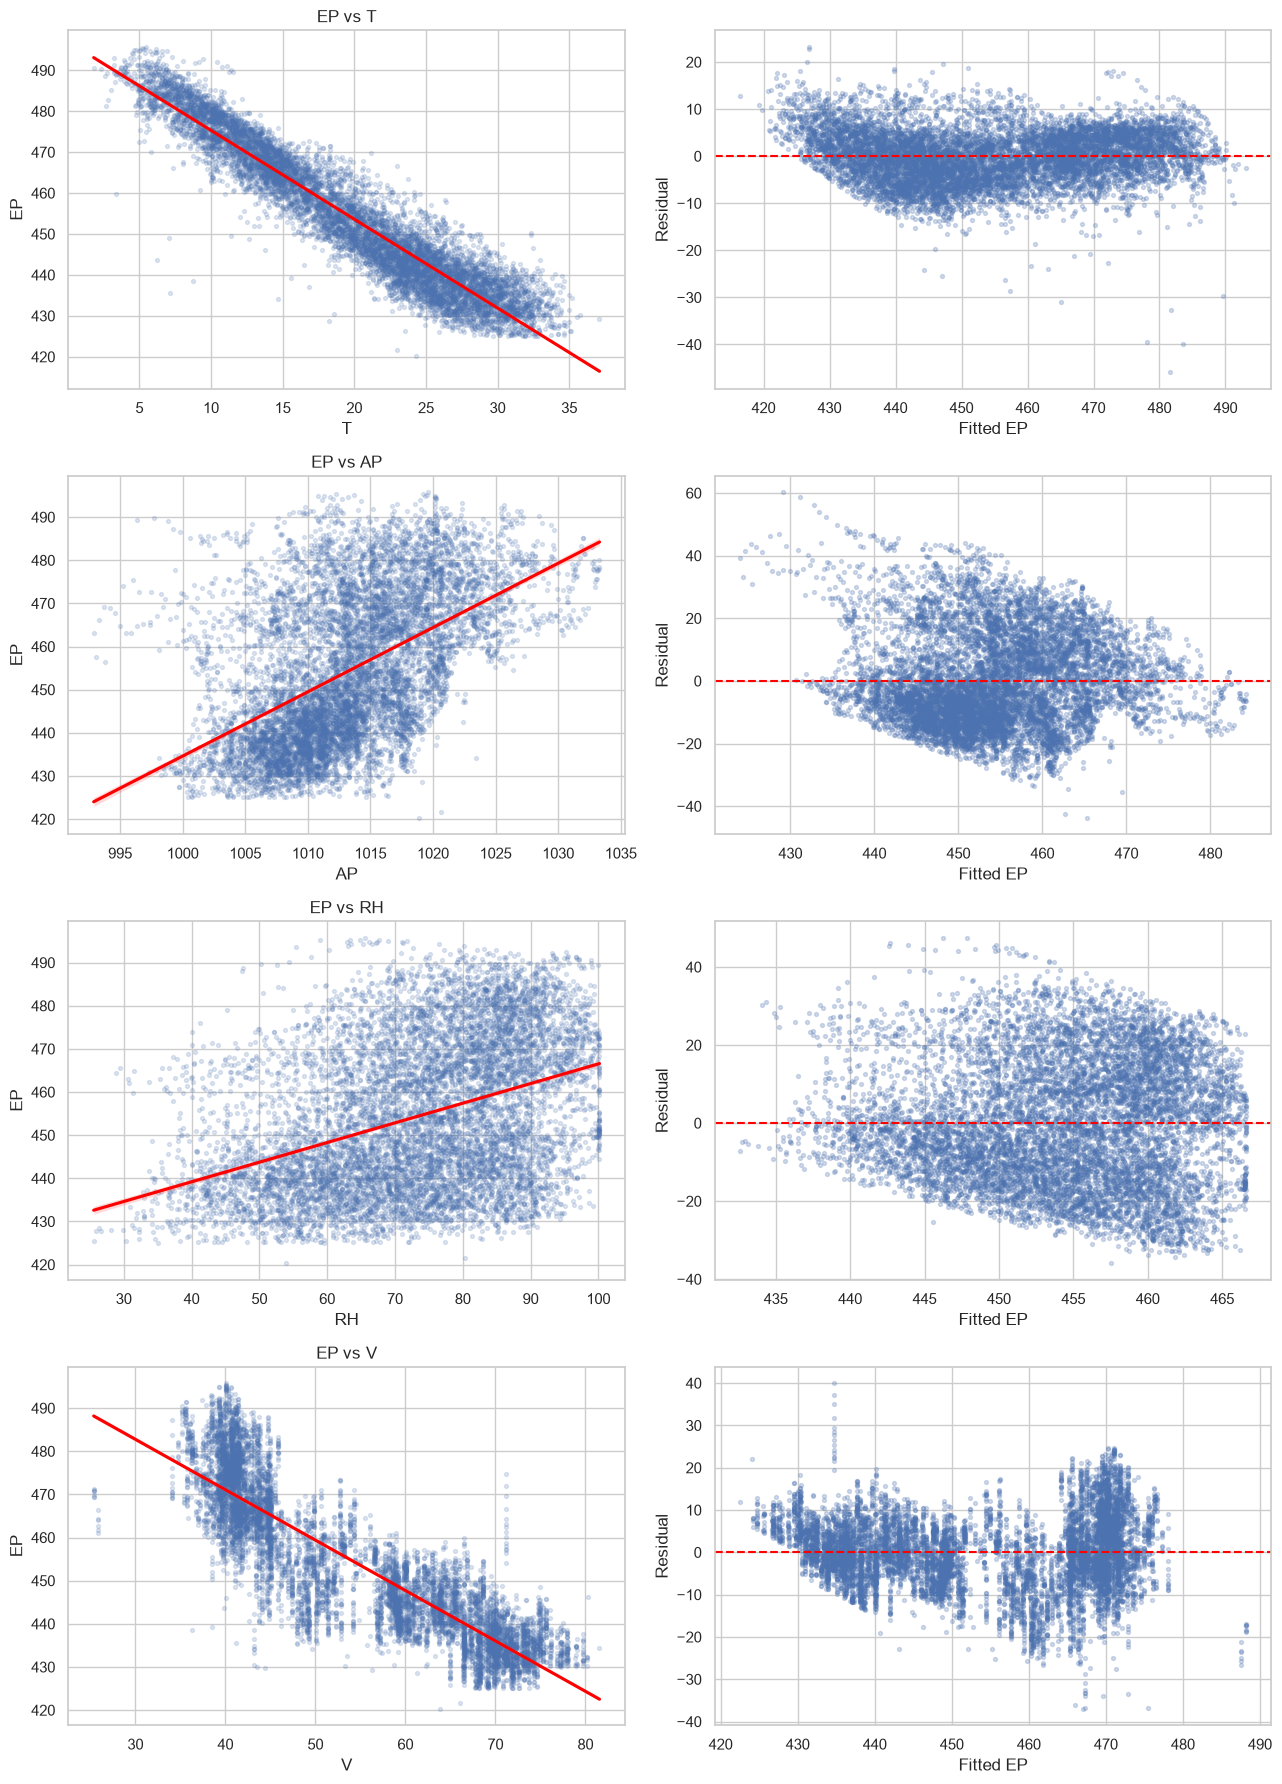

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))

for i, variable in enumerate(features):
    model = simple_models[variable]

    sns.regplot(
        data=df,
        x=variable,
        y="EP",
        scatter_kws={"alpha": 0.18, "s": 8},
        line_kws={"color": "red"},
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(
        f"EP vs {variable}"
    )

    axes[i, 1].scatter(
        model.fittedvalues,
        model.resid,
        s=8,
        alpha=0.25
    )

    axes[i, 1].axhline(
        0,
        color="red",
        linestyle="--"
    )

    axes[i, 1].set_xlabel("Fitted EP")
    axes[i, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


### 1(c) Results and Analysis

**1. Regression Results**

Four simple linear regression models were fitted to predict energy output (EP) using each predictor separately.

| Predictor | Coefficient | R² | p-value |
|---|---:|---:|---:|
| T | -2.1713 | 0.8989 | < 0.001 |
| AP | 1.4899 | 0.2688 | < 0.001 |
| RH | 0.4557 | 0.1519 | < 0.001 |
| V | -1.1681 | 0.7565 | < 0.001 |

**2. Statistical Significance and Interpretation**

All four predictors are statistically significant at the 0.05 significance level.

- **Temperature (T):** T has a strong negative association with EP. A one-unit increase in T is associated with an estimated 2.1713-unit decrease in EP. With an R² of 0.8989, this model explains approximately 89.89% of the variation in EP.

- **Ambient Pressure (AP):** AP has a positive association with EP. A one-unit increase in AP is associated with an estimated 1.4899-unit increase in EP. Its R² of 0.2688 indicates relatively limited explanatory power compared with T and V.

- **Relative Humidity (RH):** RH has a positive association with EP. A one-unit increase in RH is associated with an estimated 0.4557-unit increase in EP. Its R² of 0.1519 is the lowest among the four models.

- **Exhaust Vacuum (V):** V has a strong negative association with EP. A one-unit increase in V is associated with an estimated 1.1681-unit decrease in EP. Its R² of 0.7565 indicates substantial explanatory power.

These results describe statistical associations rather than causal relationships.

**3. Residual Analysis**

The residual plots provide additional information about model adequacy.

- **T:** The relationship is approximately linear, and the residuals are relatively concentrated around zero. Nevertheless, some systematic variation and unusually large residuals remain.

- **AP:** The residuals exhibit a pronounced non-random pattern and considerable variation, suggesting that a simple linear model may not adequately capture the relationship.

- **RH:** The residual plot shows a fan-shaped pattern, indicating non-constant residual variance and possible model misspecification.

- **V:** The residuals exhibit distinct clusters and systematic patterns. This suggests that the relationship may not be fully captured by a simple linear model and warrants further investigation.

**4. Potential Outliers**

Using an absolute internally studentized residual greater than 3 as the criterion, the models identify the following numbers of potential outliers:

| Predictor | Potential outliers |
|---|---:|
| T | 42 |
| AP | 29 |
| RH | 2 |
| V | 33 |

These observations should not be removed automatically. Large residuals may result from model misspecification rather than incorrect measurements. Before removing any observations, their validity and influence should be investigated using diagnostic measures such as leverage and Cook's distance.

Therefore, no observations are removed at this stage.

**5. Conclusion**

Temperature is the strongest individual linear predictor of EP in terms of R², followed by exhaust vacuum, ambient pressure, and relative humidity. All four predictors show statistically significant associations with EP.

However, the residual plots indicate that simple linear regression does not fully capture every relationship. Multiple regression, polynomial terms, and interaction effects will be examined in the subsequent sections.

  ### 1(d) Multiple Linear Regression

Fit a multiple linear regression model using
all four predictors.

Test H0: βj = 0 for every predictor.

In [9]:
multiple_model = smf.ols(
    "EP ~ T + AP + RH + V",
    data=df
).fit()

print(multiple_model.summary())

multiple_coef_table = pd.DataFrame({
    "Coefficient": multiple_model.params.drop(
        "Intercept"
    ),
    "p-value": multiple_model.pvalues.drop(
        "Intercept"
    )
})

multiple_coef_table["Reject H0"] = (
    multiple_coef_table["p-value"] < ALPHA
)

display(multiple_coef_table)

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:33:19   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

,Coefficient,p-value,Reject H0
T,-1.977513,0.000000e+00,True
AP,0.062083,5.507109e-11,True
RH,-0.158054,3.104584e-293,True
V,-0.233916,4.375305e-215,True



### 1(d) Multiple Linear Regression — Results and Analysis

**1. Model Performance**

A multiple linear regression model was fitted using all four predictors (T, AP, RH, and V) to predict electrical energy output (EP).

The fitted regression equation is:

EP = 454.6093 - 1.9775T + 0.0621AP - 0.1581RH - 0.2339V

The model achieves an R² of 0.929 and an adjusted R² of 0.929, explaining approximately 92.9% of the observed variation in EP.

The overall F-test is statistically significant (F = 31,140, p < 0.001), providing evidence that at least one predictor is associated with EP.

**2. Statistical Significance of Individual Predictors**

At the 0.05 significance level, all four predictors are statistically significant.

| Predictor | Coefficient | p-value | Reject H₀? |
|---|---:|---:|---|
| T | -1.9775 | < 0.001 | Yes |
| AP | 0.0621 | < 0.001 | Yes |
| RH | -0.1581 | < 0.001 | Yes |
| V | -0.2339 | < 0.001 | Yes |

- **Temperature (T):** Holding the other predictors constant, a one-unit increase in T is associated with an estimated 1.9775-unit decrease in EP.

- **Ambient Pressure (AP):** Holding the other predictors constant, a one-unit increase in AP is associated with an estimated 0.0621-unit increase in EP.

- **Relative Humidity (RH):** Holding the other predictors constant, a one-unit increase in RH is associated with an estimated 0.1581-unit decrease in EP.

- **Exhaust Vacuum (V):** Holding the other predictors constant, a one-unit increase in V is associated with an estimated 0.2339-unit decrease in EP.

Since all four p-values are below 0.05, we reject the null hypothesis H₀: βj = 0 for every predictor.

**3. Comparison with Simple Linear Regression**

The multiple regression model explains 92.9% of the variation in EP, compared with 89.9% for the simple regression model using T alone.

An important finding is that the coefficient of RH changes from +0.4557 in simple regression to -0.1581 in multiple regression. The coefficients of AP and V also decrease substantially in magnitude after adjusting for the other predictors.

These changes suggest that correlations among the predictors influence their estimated associations with EP.

**4. Model Diagnostics**

The condition number is relatively large (2.13 × 10⁵), indicating potential numerical instability. Differences in variable scales and possible multicollinearity should be investigated further, for example using variance inflation factors (VIF).

The reported standard errors and p-values are based on the conventional OLS assumptions.

**5. Conclusion**

All four predictors show statistically significant associations with EP after controlling for the other variables.

The multiple regression model has a higher in-sample R² than any of the individual simple regression models. However, its predictive performance on unseen data still needs to be evaluated using a separate test set.

### 1(e)

Compare the simple-regression and multiple-regression
coefficients. Plot simple coefficients on the x-axis
and multiple-regression coefficients on the y-axis.

,Simple slope,Multiple coefficient
T,-2.171320,-1.977513
AP,1.489872,0.062083
RH,0.455650,-0.158054
V,-1.168135,-0.233916


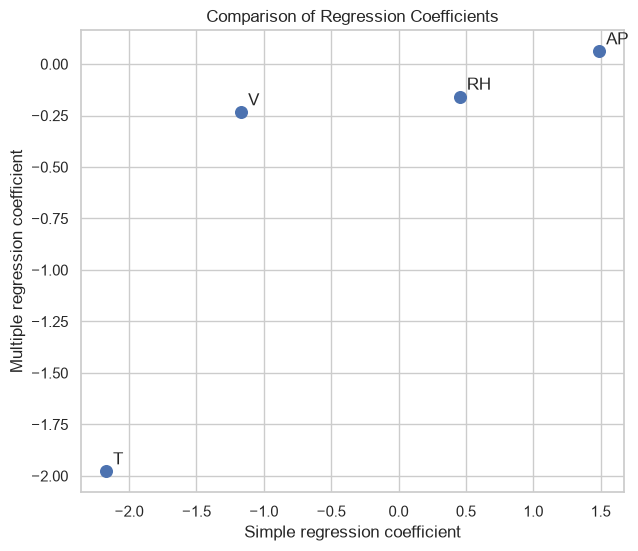

In [10]:
coefficient_comparison = pd.DataFrame({
    "Simple slope": pd.Series({
        x: simple_models[x].params[x]
        for x in features
    }),
    "Multiple coefficient": multiple_model.params[features]
})

display(coefficient_comparison)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    coefficient_comparison["Simple slope"],
    coefficient_comparison["Multiple coefficient"],
    s=70
)

for name, row in coefficient_comparison.iterrows():
    ax.annotate(
        name,
        (
            row["Simple slope"],
            row["Multiple coefficient"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Simple regression coefficient")
ax.set_ylabel("Multiple regression coefficient")
ax.set_title("Comparison of Regression Coefficients")

plt.show()


### 1(e) Comparison of Simple and Multiple Regression Coefficients

**1. Coefficient Comparison**

The coefficients obtained from simple and multiple linear regression are summarized below.

| Predictor | Simple Regression | Multiple Regression |
|---|---:|---:|
| T | -2.1713 | -1.9775 |
| AP | 1.4899 | 0.0621 |
| RH | 0.4557 | -0.1581 |
| V | -1.1681 | -0.2339 |

**2. Interpretation**

- **Temperature (T):** The coefficient remains negative, changing from -2.1713 to -1.9775. The relatively small change suggests that the estimated negative association between temperature and energy output remains substantial after controlling for the other predictors.

- **Ambient Pressure (AP):** The coefficient decreases substantially from 1.4899 to 0.0621 but remains positive. This indicates that the positive association observed in simple regression becomes much smaller after accounting for the other variables.

- **Relative Humidity (RH):** The coefficient changes from +0.4557 to -0.1581. This reversal suggests that the marginal association between RH and EP differs from their association when the other predictors are held constant.

- **Exhaust Vacuum (V):** The coefficient remains negative but decreases in magnitude from -1.1681 to -0.2339. This suggests that some of the association observed in simple regression overlaps with information provided by the other predictors.

**3. Interpretation of the Coefficient Plot**

The scatterplot illustrates the differences between the simple and multiple regression coefficients. Each point represents one predictor, with its simple regression coefficient on the x-axis and its multiple regression coefficient on the y-axis.

The substantial changes in AP, RH, and V suggest that relationships among the predictors influence their estimated coefficients. Temperature shows a comparatively smaller change.

**4. Conclusion**

Simple regression estimates the association between each predictor and EP separately, whereas multiple regression estimates the association after adjusting for the other predictors.

The observed coefficient changes indicate that accounting for other variables is important when interpreting these relationships. However, the coefficients do not establish causality, and their magnitudes should not be compared directly across predictors measured in different units.
  
                                                                                                                                         
                                                                                                1(f) Nonlinear Regression

Fit a cubic polynomial regression for each predictor
and test for evidence of nonlinear association.

/var/folders/ds/3_3tsk_j7gscpc1r44nxkmfw0000gn/T/ipykernel_1272/3759809130.py:16: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


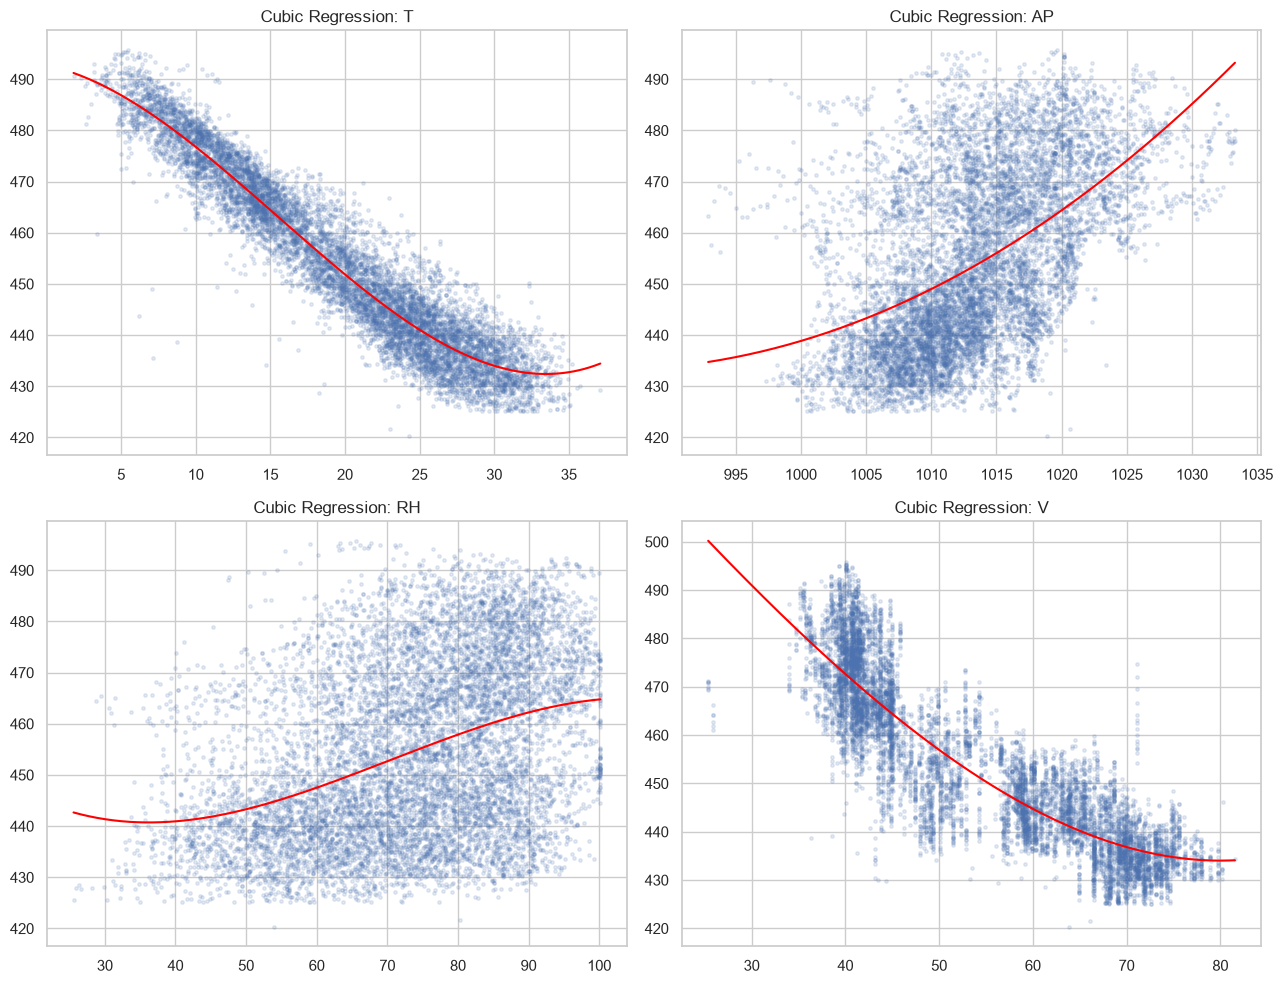

,Quadratic p-value,Cubic p-value,Joint p-value
Predictor,,,
T,8.833045e-73,3.652185e-110,3.478379e-285
AP,3.666705e-17,8.264146e-18,3.646813e-19
RH,9.395430e-06,1.440279e-05,3.799622e-05
V,7.684969e-01,1.373489e-02,7.040304e-165


In [16]:
cubic_models = {}
nonlinear_records = []

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for variable, ax in zip(features, axes.ravel()):
    formula = (
        f"EP ~ {variable}"
        f" + I({variable} ** 2)"
        f" + I({variable} ** 3)"
    )

    model = smf.ols(
        formula,
        data=df
    ).fit()

    cubic_models[variable] = model

    f_stat, joint_p, df_diff = (
        model.compare_f_test(
            simple_models[variable]
        )
    )

    nonlinear_records.append({
        "Predictor": variable,
        "Quadratic p-value":
            model.pvalues[f"I({variable} ** 2)"],
        "Cubic p-value":
            model.pvalues[f"I({variable} ** 3)"],
        "Joint p-value": joint_p
    })

    xs = np.linspace(
        df[variable].min(),
        df[variable].max(),
        200
    )

    ax.scatter(
        df[variable],
        df["EP"],
        s=6,
        alpha=0.15
    )

    ax.plot(
        xs,
        model.predict(
            pd.DataFrame({variable: xs})
        ),
        color="red"
    )

    ax.set_title(f"Cubic Regression: {variable}")

plt.tight_layout()
plt.show()

nonlinear_results = pd.DataFrame(
    nonlinear_records
).set_index("Predictor")

display(nonlinear_results)


### 1(f) Nonlinear Regression — Results and Analysis

**1. Statistical Results**

Cubic polynomial regression models were fitted separately for each predictor to investigate potential nonlinear associations with electrical energy output (EP).

Each model includes linear, quadratic, and cubic terms:

EP = β₀ + β₁X + β₂X² + β₃X³ + ε

The following table summarizes the statistical results.

| Predictor | Quadratic p-value | Cubic p-value | Joint p-value |
|---|---:|---:|---:|
| T | 8.83e-73 | 3.65e-110 | 3.48e-285 |
| AP | 3.67e-17 | 8.26e-18 | 3.65e-19 |
| RH | 9.40e-06 | 1.44e-05 | 3.80e-05 |
| V | 0.7685 | 0.0137 | 7.04e-165 |

The joint F-test compares the cubic model with the corresponding simple linear regression model. The null hypothesis is that both additional polynomial coefficients are zero:

H₀: β₂ = β₃ = 0.

**2. Interpretation of Individual Predictors**

**Temperature (T)**

Both the quadratic and cubic terms are highly statistically significant (p < 0.001). The joint F-test also provides strong evidence of nonlinearity.

The fitted curve shows a decreasing but nonlinear relationship between temperature and energy output. The rate of decrease changes across the temperature range, and the curve flattens at higher temperatures.

**Ambient Pressure (AP)**

The initial results indicate statistically significant quadratic and cubic terms (p < 0.001). The fitted curve suggests an increasing, nonlinear relationship between AP and EP.

However, a SingularMatrixWarning occurred during polynomial model fitting. The AP polynomial model is especially susceptible to numerical instability because AP values are relatively large and its polynomial terms can be poorly conditioned. The significance results should therefore be verified using centered predictors before drawing a definitive conclusion.

**Relative Humidity (RH)**

Both the quadratic and cubic terms have p-values below 0.05. The joint F-test is also statistically significant.

The fitted curve shows a nonlinear relationship between RH and EP, with a relatively flat region at lower humidity and an increasing trend at higher humidity. The statistical results support investigating a nonlinear specification rather than relying exclusively on simple linear regression.

**Exhaust Vacuum (V)**

The quadratic term is not statistically significant (p = 0.7685), whereas the cubic term is statistically significant (p = 0.0137).

The joint F-test is highly significant, indicating that the polynomial model provides evidence of a nonlinear association beyond the simple linear model.

The fitted curve shows a nonlinear decreasing relationship, with the slope becoming flatter at higher exhaust vacuum values.

**3. Overall Conclusion**

The initial joint tests indicate evidence of nonlinear associations between EP and all four predictors. Temperature and exhaust vacuum exhibit particularly clear nonlinear patterns in their fitted curves.

The statistical interpretation of the affected polynomial model should be confirmed after addressing the numerical rank-deficiency warning. These results motivate further investigation of polynomial terms in the subsequent multivariable modeling tasks.


### 1(g) Interaction Terms

Fit a full linear regression model with all
pairwise interactions between predictors.

In [17]:
interaction_terms = [
    f"{a}:{b}"
    for a, b in combinations(features, 2)
]

interaction_formula = (
    "EP ~ " +
    " + ".join(features + interaction_terms)
)

interaction_model = smf.ols(
    interaction_formula,
    data=df
).fit()

print(interaction_model.summary())

interaction_p_values = (
    interaction_model.pvalues[interaction_terms]
)

display(
    pd.DataFrame({
        "p-value": interaction_p_values,
        "Significant": interaction_p_values < ALPHA
    })
)

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:47:46   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

,p-value,Significant
T:AP,4.520509e-01,False
T:RH,1.216944e-10,True
T:V,3.333358e-117,True
AP:RH,3.360557e-02,True
AP:V,2.877026e-07,True
RH:V,8.619366e-02,False



### 1(g) Interaction Effects — Results and Analysis

**1. Model Performance**

A multiple linear regression model was fitted using all four predictors (T, AP, RH, and V) and their six possible pairwise interaction terms.

The model achieves an R² of 0.936 and an adjusted R² of 0.936, explaining approximately 93.6% of the observed variation in electrical energy output (EP).

The overall F-test is statistically significant (F ≈ 14,050, p < 0.001).

**2. Statistical Significance of Interaction Terms**

At a significance level of α = 0.05, the results are:

| Interaction | Coefficient | p-value | Significant? |
|---|---:|---:|---|
| T:AP | 0.0018 | 0.4521 | No |
| T:RH | -0.0052 | 1.22e-10 | Yes |
| T:V | 0.0210 | 3.33e-117 | Yes |
| AP:RH | -0.0016 | 0.0336 | Yes |
| AP:V | 0.0068 | 2.88e-07 | Yes |
| RH:V | 0.0008 | 0.0862 | No |

Four of the six pairwise interaction terms are statistically significant.

**3. Interpretation of Significant Interactions**

- **T × RH:** The negative interaction coefficient (-0.0052) indicates that the estimated effect of temperature on EP becomes more negative as relative humidity increases, holding the other predictors constant.

- **T × V:** The positive interaction coefficient (0.0210) indicates that the estimated effect of temperature on EP becomes more positive (or less negative) as exhaust vacuum increases, holding the other predictors constant.

- **AP × RH:** The negative coefficient (-0.0016) indicates that the estimated effect of ambient pressure on EP decreases as relative humidity increases.

- **AP × V:** The positive coefficient (0.0068) indicates that the estimated effect of ambient pressure on EP increases as exhaust vacuum increases.

These results suggest that the association between certain predictors and EP depends on the values of other predictors.

**4. Non-Significant Interaction Terms**

The T:AP (p = 0.4521) and RH:V (p = 0.0862) interaction terms are not statistically significant at α = 0.05.

Therefore, we fail to reject the null hypothesis that each of these interaction coefficients equals zero.

**5. Model Diagnostics and Limitations**

The model has a large condition number (1.70 × 10⁸), suggesting potential numerical instability arising from differences in variable scales and/or multicollinearity.

Centering the predictors before constructing interaction terms may improve numerical conditioning.

Although T is not individually significant in this model (p = 0.067), it should not be removed automatically because it participates in statistically significant interaction terms. The hierarchical principle requires retaining the corresponding main effects when interaction terms are included.

**6. Conclusion**

The results provide statistical evidence that several pairs of predictors interact in their association with electrical energy output.

Four interactions (T:RH, T:V, AP:RH, and AP:V) are statistically significant at the 0.05 level.

The interaction model achieves an R² of 0.936, compared with 0.929 for the multiple linear regression model without interactions. However, the improvement in predictive performance must be evaluated on unseen test data.


### 1(h) Model Improvement

Use a random 70/30 train-test split.

Compare a baseline linear model with a model
containing quadratic terms and interactions.

Perform backward elimination while respecting
the hierarchy of model terms.

In [18]:
train_df, test_df = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
print("Training set:", train_df.shape, "Test set:", test_df.shape)

baseline_train_model = smf.ols("EP ~ " + " + ".join(features), data=train_df).fit()
squared_terms = [f"I({x} ** 2)" for x in features]
remaining_terms = features + squared_terms + interaction_terms
removed_terms = []

def safely_removable(term, current_terms):
    if term not in features:
        return True
    if f"I({term} ** 2)" in current_terms:
        return False
    if any(term in t.split(":") for t in interaction_terms if t in current_terms):
        return False
    return True

while True:
    selected_formula = "EP ~ " + (" + ".join(remaining_terms) if remaining_terms else "1")
    selected_model = smf.ols(selected_formula, data=train_df).fit()
    eligible = [t for t in remaining_terms if safely_removable(t, remaining_terms)]
    if not eligible:
        break
    worst_term = max(eligible, key=lambda t: selected_model.pvalues[t])
    worst_p = selected_model.pvalues[worst_term]
    if worst_p <= ALPHA:
        break
    removed_terms.append((worst_term, float(worst_p)))
    remaining_terms.remove(worst_term)

selected_formula = "EP ~ " + (" + ".join(remaining_terms) if remaining_terms else "1")
selected_model = smf.ols(selected_formula, data=train_df).fit()
print("Final selected formula:", selected_formula)
print("Removed terms (p-value at removal):", removed_terms)
print(selected_model.summary())

linear_model_results = pd.DataFrame([
    {
        "Model": "Linear: four original predictors",
        "Train MSE": mean_squared_error(train_df["EP"], baseline_train_model.predict(train_df)),
        "Test MSE": mean_squared_error(test_df["EP"], baseline_train_model.predict(test_df)),
    },
    {
        "Model": "Selected interactions and quadratics",
        "Train MSE": mean_squared_error(train_df["EP"], selected_model.predict(train_df)),
        "Test MSE": mean_squared_error(test_df["EP"], selected_model.predict(test_df)),
    },
])
display(linear_model_results)

Training set: (6697, 5) Test set: (2871, 5)
Final selected formula: EP ~ T + AP + RH + V + I(T ** 2) + I(AP ** 2) + I(RH ** 2) + T:AP + T:RH + T:V + AP:RH
Removed terms (p-value at removal): [('RH:V', 0.8673823758796343), ('I(V ** 2)', 0.6077327700529911), ('AP:V', 0.357825503840225)]
                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:52:16   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Cov

,Model,Train MSE,Test MSE
0,Linear: four original predictors,20.580840,21.239857
1,Selected interactions and quadratics,17.890843,18.660040



### 1(h) Model Improvement — Results and Analysis

**1. Training and Test Sets**

The dataset was randomly divided into a 70% training set and a 30% test set.

- Training set: 6,697 observations
- Test set: 2,871 observations

Two regression models were fitted and compared: a baseline linear regression model using all four original predictors and an improved model incorporating quadratic terms and pairwise interactions.

**2. Model Selection**

The initial extended model included all four predictors, their quadratic terms, and all six pairwise interactions.

Backward elimination was performed using a significance level of 0.05 while respecting the hierarchical principle for interaction terms.

The following terms were removed:

| Removed term | p-value at removal |
|---|---:|
| RH:V | 0.8674 |
| V² | 0.6077 |
| AP:V | 0.3578 |

The final selected model retained:

- Main effects: T, AP, RH, and V
- Quadratic terms: T², AP², and RH²
- Interaction terms: T:AP, T:RH, T:V, and AP:RH

All retained terms have reported p-values below 0.05 in the final fitted model.

**3. Model Performance**

The selected model achieved an R² of 0.938 and an adjusted R² of 0.938 on the training data, explaining approximately 93.8% of the observed variation in EP.

The training and test MSEs are summarized below.

| Model | Training MSE | Test MSE |
|---|---:|---:|
| Baseline linear regression | 20.5808 | 21.2399 |
| Selected nonlinear and interaction model | 17.8908 | 18.6600 |

Compared with the baseline model, the selected model reduced training MSE by approximately 13.1% and test MSE by approximately 12.1%.

**4. Interpretation**

The selected model achieved lower training and test MSEs than the baseline linear regression model.

The improvement suggests that incorporating quadratic terms and interactions helps capture relationships between the predictors and electrical energy output that are not fully represented by a model containing only the original predictors.

The test MSE remains slightly higher than the training MSE, but both errors decreased after model improvement. This provides evidence of improved predictive performance on the held-out test set in this experiment.

The selection process also illustrates that not every possible polynomial or interaction term is necessary. Removing insignificant terms produces a more compact model while retaining the main effects associated with the selected interactions.

**5. Model Limitations**

The selected model has a very large condition number (2.83 × 10¹⁰), suggesting potential numerical instability caused by differences in variable scales and/or multicollinearity.

Centering or standardizing the predictors before constructing polynomial and interaction terms may improve numerical conditioning.

Additionally, the results are based on a single random train-test split. Cross-validation could provide a more reliable estimate of predictive performance.

**6. Conclusion**

The selected nonlinear and interaction model achieved a lower test MSE (18.6600) than the baseline linear regression model (21.2399).

Therefore, adding selected quadratic and interaction terms improved predictive accuracy on the held-out test set in this experiment.

These results suggest that nonlinear associations and interactions are useful when modeling electrical energy output.


### 1(i) KNN Regression

Perform KNN regression using raw and normalized
features for k = 1, 2, ..., 100.

Plot training and test MSE against 1/k.

In [19]:
X_train_raw = train_df[features].to_numpy()
X_test_raw = test_df[features].to_numpy()
y_train = train_df["EP"].to_numpy()
y_test = test_df["EP"].to_numpy()

scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train_raw)
X_test_normalized = scaler.transform(X_test_raw)

K_MAX = 100
k_grid = np.arange(1, K_MAX + 1)

def knn_mse_curves(Xtr, Xte, ytr, yte, feature_type):
    neighbor_model = KNeighborsRegressor(n_neighbors=K_MAX, weights="uniform", n_jobs=-1)
    neighbor_model.fit(Xtr, ytr)
    train_indices = neighbor_model.kneighbors(Xtr, n_neighbors=K_MAX, return_distance=False)
    test_indices = neighbor_model.kneighbors(Xte, n_neighbors=K_MAX, return_distance=False)
    denominators = k_grid[np.newaxis, :]
    predictions_train = np.cumsum(ytr[train_indices], axis=1) / denominators
    predictions_test = np.cumsum(ytr[test_indices], axis=1) / denominators
    train_mse = np.mean((predictions_train - ytr[:, None]) ** 2, axis=0)
    test_mse = np.mean((predictions_test - yte[:, None]) ** 2, axis=0)
    return pd.DataFrame({
        "Feature type": feature_type,
        "k": k_grid,
        "1/k": 1 / k_grid,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
    })

raw_curve = knn_mse_curves(X_train_raw, X_test_raw, y_train, y_test, "Raw")
normalized_curve = knn_mse_curves(X_train_normalized, X_test_normalized, y_train, y_test, "Normalized")
knn_results = pd.concat([raw_curve, normalized_curve], ignore_index=True)

best_knn_rows = []
for feature_type, group in knn_results.groupby("Feature type", sort=False):
    best = group.loc[group["Test MSE"].idxmin()]
    best_knn_rows.append(best)
best_knn_summary = pd.DataFrame(best_knn_rows)[["Feature type", "k", "Train MSE", "Test MSE"]].reset_index(drop=True)
best_knn_summary["k"] = best_knn_summary["k"].astype(int)
display(best_knn_summary)

,Feature type,k,Train MSE,Test MSE
0,Raw,5,10.600769,15.726820
1,Normalized,4,8.454348,14.291333


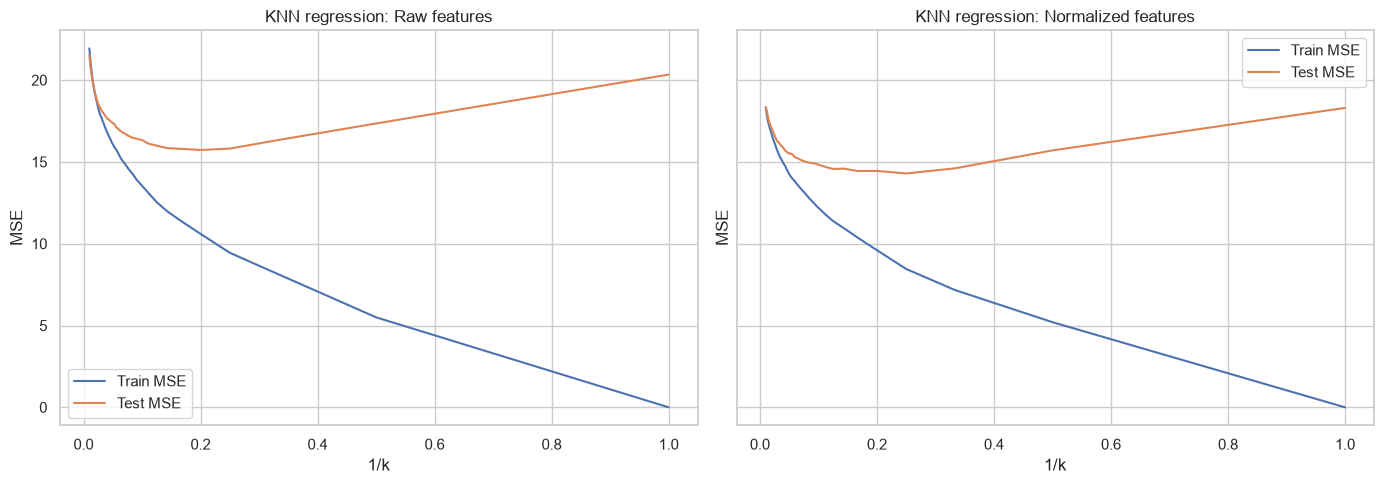

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (label, curve) in zip(axes, [("Raw", raw_curve), ("Normalized", normalized_curve)]):
    ordered = curve.sort_values("1/k")
    ax.plot(ordered["1/k"], ordered["Train MSE"], label="Train MSE")
    ax.plot(ordered["1/k"], ordered["Test MSE"], label="Test MSE")
    ax.set(title=f"KNN regression: {label} features", xlabel="1/k", ylabel="MSE")
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()


### 1(i) KNN Regression — Results and Analysis

**1. Optimal K and Model Performance**

KNN regression was performed using both raw and Min-Max normalized features. Values of k ranging from 1 to 100 were evaluated, and the optimal k was selected based on the lowest test MSE.

| Feature Type | Optimal k | Training MSE | Test MSE |
|---|---:|---:|---:|
| Raw | 5 | 10.6008 | 15.7268 |
| Normalized | 4 | 8.4543 | 14.2913 |

The optimal number of neighbors is 5 for raw features and 4 for normalized features.

**2. Effect of Normalization**

The normalized KNN model achieves a lower test MSE (14.2913) than the raw KNN model (15.7268), representing an improvement of approximately 9.13%.

Normalization is particularly important for KNN because the algorithm relies on distances between observations. Without normalization, predictors with larger numerical ranges may dominate the Euclidean distance calculation.

Min-Max normalization scales the predictors to a common range, allowing them to contribute more comparably to the distance calculation.

In this experiment, normalization improves predictive performance on the held-out test set.

**3. Training and Test Error Curves**

The plots illustrate how training and test MSE change with 1/k.

- **Large k (small 1/k):** Both models have relatively high training and test errors. Using too many neighbors produces smoother predictions that may underfit the data.

- **Intermediate k:** As k decreases, the test error initially declines. The minimum test MSE occurs at k = 5 for raw features and k = 4 for normalized features.

- **Small k (large 1/k):** Training error continues to decrease as k approaches 1, reaching zero at k = 1. However, test error increases after passing the optimal k, indicating overfitting.

These patterns illustrate the bias-variance trade-off in KNN regression.

**4. Overfitting and Generalization**

At their respective optimal k values, both models have higher test MSE than training MSE.

For raw features:
- Training MSE = 10.6008
- Test MSE = 15.7268

For normalized features:
- Training MSE = 8.4543
- Test MSE = 14.2913

Although the normalized model has a slightly larger train-test MSE gap, it achieves lower absolute errors on both datasets.

The zero training error at k = 1 does not imply good predictive performance. Instead, the corresponding increase in test error demonstrates the risk of overfitting.

**5. Conclusion**

Normalization improves KNN regression performance in this experiment. The normalized model with k = 4 achieves the lowest test MSE of 14.2913, compared with 15.7268 for the raw model with k = 5.

The results also demonstrate the importance of selecting an appropriate k. Very small k values may lead to overfitting, while excessively large k values may cause underfitting.

The normalized KNN model will be compared with the regression models from Section 1(h) in the next section.


### 1(j) Final Model Comparison

Compare KNN regression with the linear regression
model that achieved the lowest test MSE.

In [21]:
best_linear = linear_model_results.loc[
    linear_model_results["Test MSE"].idxmin()
]

comparison = pd.concat([
    pd.DataFrame([{
        "Model": best_linear["Model"],
        "Train MSE": best_linear["Train MSE"],
        "Test MSE": best_linear["Test MSE"]
    }]),

    best_knn_summary.rename(
        columns={"Feature type": "Model"}
    ).assign(
        Model=lambda x:
            "KNN (" + x["Model"].str.lower() + ")"
    )[
        ["Model", "Train MSE", "Test MSE"]
    ]
], ignore_index=True)

display(
    comparison.sort_values(
        "Test MSE",
        ignore_index=True
    )
)

,Model,Train MSE,Test MSE
0,KNN (normalized),8.454348,14.291333
1,KNN (raw),10.600769,15.726820
2,Selected interactions and quadratics,17.890843,18.660040



### 1(j) Comparison of KNN and Linear Regression

**1. Model Performance**

The two KNN regression models from Section 1(i) were compared with the selected regression model containing quadratic and interaction terms from Section 1(h). All three models were evaluated using the same 70% training and 30% test split.

| Model | Train MSE | Test MSE |
|---|---:|---:|
| KNN (normalized, k = 4) | 8.4543 | 14.2913 |
| KNN (raw, k = 5) | 10.6008 | 15.7268 |
| Selected quadratic and interaction regression | 17.8908 | 18.6600 |

**2. Comparison of Predictive Performance**

The normalized KNN model achieved the lowest test MSE of 14.2913, followed by raw KNN with a test MSE of 15.7268.

Compared with the selected regression model, normalized KNN reduced the test MSE by approximately 23.4%, while raw KNN reduced it by approximately 15.7%.

Normalization further reduced the KNN test MSE by approximately 9.1% compared with using raw features.

These results indicate that both KNN models achieved lower prediction errors than the selected regression model on the held-out test set.

**3. Interpretation**

The selected regression model incorporates quadratic terms and interactions to capture nonlinear relationships. However, it still assumes a specific functional form.

KNN regression is a nonparametric method that makes predictions based on nearby observations. This flexibility allows it to capture local patterns without explicitly specifying polynomial or interaction terms.

The lower test errors of both KNN models suggest that local relationships may be useful for predicting electrical energy output in this dataset.

Feature normalization also improves KNN performance by preventing predictors with larger numerical ranges from dominating the Euclidean distance calculation.

**4. Generalization and Overfitting**

The normalized KNN model has a training MSE of 8.4543 and a test MSE of 14.2913, giving a train-test gap of approximately 5.8370.

The selected regression model has a training MSE of 17.8908 and a test MSE of 18.6600, giving a smaller gap of approximately 0.7692.

Although KNN achieves lower errors, its larger train-test gap suggests greater sensitivity to the training data. The regression model exhibits more similar training and test errors but has a higher overall prediction error.

These results are based on a single random train-test split, so repeated evaluation or cross-validation would help assess their stability.

**5. Conclusion**

Among the three models evaluated, normalized KNN with k = 4 achieved the lowest test MSE (14.2913), compared with 15.7268 for raw KNN and 18.6600 for the selected regression model.

The results demonstrate the usefulness of nonlinear, distance-based methods for this prediction task and the importance of feature normalization for KNN regression.

However, the selected regression model remains more directly interpretable through its estimated coefficients, while KNN offers greater flexibility in capturing local relationships.
  

References
1. UCI Machine Learning Repository, Combined Cycle Power Plant (dataset 294): https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant
2. statsmodels OLS/formula documentation: https://www.statsmodels.org/stable/regression.html
3. scikit-learn Nearest Neighbors Regression: https://scikit-learn.org/stable/modules/neighbors.html


## 2. ISLR 2.4.1

For each scenario, compare the expected performance of flexible and inflexible statistical learning methods.

### (a) Extremely large sample size and few predictors

**Answer: A flexible method would generally perform better.**

When the sample size is extremely large and the number of predictors is small, there are sufficient observations to estimate complex relationships reliably. A flexible method can capture more complicated patterns while reducing the risk of overfitting associated with limited training data.

Therefore, a flexible method may achieve lower bias and better predictive performance.

### (b) Extremely many predictors and few observations

**Answer: An inflexible method would generally perform better.**

When the number of predictors is extremely large relative to the sample size, flexible methods are more likely to overfit the training data.

The curse of dimensionality makes it difficult to estimate complex relationships accurately with limited observations.

Inflexible methods generally have lower variance and may achieve better generalization performance in this situation.

### (c) Highly nonlinear relationship

**Answer: A flexible method would generally perform better.**

Flexible methods can capture complex nonlinear relationships between predictors and the response.

In contrast, inflexible methods may impose overly restrictive assumptions, resulting in high bias and underfitting.

Therefore, a flexible method would generally be preferable when the underlying relationship is highly nonlinear.

### (d) Extremely high variance of the error terms

**Answer: An inflexible method would generally perform better.**

When the variance of the error terms is extremely high, the observations contain substantial noise.

Flexible methods may fit random fluctuations rather than the underlying relationship, resulting in overfitting and high variance.

Inflexible methods are generally less sensitive to noise and may achieve better test performance.

However, neither method can eliminate irreducible error.



## 3. ISLR 2.4.7

### K-Nearest Neighbors Classification

The training dataset contains six observations, three predictors, and one qualitative response variable.

We wish to predict the class of a new observation:

\[
X_{\text{test}}=(0,0,0)
\]

The Euclidean distance between each training observation and the test point is calculated as:

\[
d_i=\sqrt{(X_{i1}-0)^2+(X_{i2}-0)^2+(X_{i3}-0)^2}
\]

### (a) Euclidean Distance Calculation

The distances are:

| Observation | Class | Euclidean Distance |
|---|---|---:|
| 1 | Red | 3.000 |
| 2 | Red | 2.000 |
| 3 | Red | 3.162 |
| 4 | Green | 2.236 |
| 5 | Green | 1.414 |
| 6 | Red | 1.732 |


In [22]:
import numpy as np
import pandas as pd

# Training data provided in the question
X_train_247 = np.array([
    [0, 3, 0],
    [2, 0, 0],
    [0, 1, 3],
    [0, 1, 2],
    [-1, 0, 1],
    [1, 1, 1]
])

y_train_247 = np.array([
    "Red", "Red", "Red",
    "Green", "Green", "Red"
])

# Test observation
X_test_247 = np.array([0, 0, 0])

# Calculate Euclidean distances
distances_247 = np.linalg.norm(
    X_train_247 - X_test_247,
    axis=1
)

# Display observations sorted by distance
results_247 = pd.DataFrame({
    "Observation": np.arange(1, 7),
    "Distance": distances_247,
    "Class": y_train_247
})

results_247 = results_247.sort_values(
    "Distance"
).reset_index(drop=True)

display(results_247.round(3))

# Predictions using majority voting
for k in [1, 3]:
    nearest = results_247.head(k)

    prediction = (
        nearest["Class"]
        .value_counts()
        .idxmax()
    )

    print(f"K = {k}: {prediction}")

,Observation,Distance,Class
0,5,1.414,Green
1,6,1.732,Red
2,2,2.000,Red
3,4,2.236,Green
4,1,3.000,Red
5,3,3.162,Red


K = 1: Green
K = 3: Red



### (b) Prediction When K = 1

**Answer: Green.**

The nearest observation is observation 5, with a Euclidean distance of approximately 1.414.

Its class is Green.

Since K = 1, the prediction is determined by the class of the single nearest neighbor.

Therefore, the predicted class is **Green**.

### (c) Prediction When K = 3

**Answer: Red.**

The three nearest observations are:

| Observation | Distance | Class |
|---|---:|---|
| 5 | 1.414 | Green |
| 6 | 1.732 | Red |
| 2 | 2.000 | Red |

Among the three nearest neighbors, two belong to the Red class and one belongs to the Green class.

Using majority voting, the predicted class is **Red**.

### (d) Optimal K for a Highly Nonlinear Bayes Decision Boundary

**Answer: A relatively small K would generally be preferable.**

A small value of K produces a more flexible decision boundary, allowing KNN to capture complex local relationships.

In contrast, a large K averages over more neighboring observations and produces a smoother decision boundary. This may lead to underfitting when the true Bayes decision boundary is highly nonlinear.

Therefore, a relatively small K would generally be preferable, although an excessively small K can increase variance and the risk of overfitting.
